# Interpretabilità e analisi dei possibili bias

In questo notebook analizzo il modello finale con SHAP (*SHapley Additive exPlanations*). L'obiettivo è capire quali variabili influenzano maggiormente le predizioni nel complesso e quali contributi spiegano una singola predizione.

Aggiungo anche una semplice analisi per fasce d'età. Non è una valutazione completa della fairness, ma permette di verificare se le metriche cambiano tra sottogruppi con numerosità diverse.

## 1. Che cosa misura SHAP?

SHAP assegna a ogni variabile un contributo alla probabilità stimata. Un contributo positivo aumenta la probabilità della classe positiva, mentre un contributo negativo la riduce.

Userò due prospettive:

- **importanza globale**: media dei contributi assoluti su molte osservazioni;
- **spiegazione locale**: contributi delle variabili per una singola osservazione.

Questi contributi descrivono il comportamento del modello e non rappresentano relazioni causali o indicazioni cliniche.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from pathlib import Path
import sys
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
COLUMNS = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age', 'outcome']
FEATURES = COLUMNS[:-1]
project_root = Path('..').resolve() if (Path('..') / 'src').exists() else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
model_path = project_root / 'models' / 'diabetes_model.joblib'
data_path = project_root / 'data' / 'raw' / 'diabetes.csv'
if not model_path.exists() or not data_path.exists():
    raise FileNotFoundError('Eseguire prima `python -m src.train` e preparare il dataset locale.')

from src.train import final_model

model = joblib.load(model_path)
df = pd.read_csv(data_path, header=None, names=COLUMNS)
X = df[FEATURES]
y = df['outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Modello indipendente per valutare il test set: non viene addestrato su X_test.
evaluation_model = final_model()
evaluation_model.fit(X_train, y_train)
print('Modello finale caricato correttamente.')
print(f'Per la valutazione mantengo un test set separato di {len(X_test)} osservazioni.')

/Users/alessio/Desktop/Unipi/Laboratorio di AI/medical-ml-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modello finale caricato correttamente.
Per la valutazione mantengo un test set separato di 154 osservazioni.


## 2. Spiegazioni SHAP sul modello completo

Il modello contiene preprocessing e caratteristiche polinomiali, quindi non interpreto direttamente i coefficienti trasformati. Uso invece SHAP come spiegatore model-agnostic: gli passo la pipeline completa e mantengo come nomi delle caratteristiche le otto variabili originali.

Per calcolare i contributi SHAP serve un **gruppo di riferimento** (*background*). SHAP usa questo gruppo per stimare la probabilità media del modello quando i valori specifici della persona non sono ancora considerati. Questa media è il valore di riferimento dal quale parte la spiegazione. Nel mio caso estraggo 40 osservazioni dal training set e calcolo la media delle probabilità prodotte dal modello su queste osservazioni.

Uso il training set perché il test set deve restare separato dalla fase di valutazione. In teoria potrei usare tutte le 614 osservazioni del training set, ottenendo una media leggermente più stabile; scelgo però un campione di 40 osservazioni per contenere i tempi di calcolo di uno spiegatore model-agnostic. Il campione è sufficiente per questa analisi didattica e la scelta è resa esplicita e riproducibile tramite `random_state=42`. Il test set resta utilizzato soltanto per gli esempi di spiegazione e per il controllo descrittivo delle fasce d'età.

In [2]:
background = X_train.sample(n=min(40, len(X_train)), random_state=RANDOM_STATE)
explain_data = X_test.iloc[:30].copy()

def positive_probability(data):
    frame = pd.DataFrame(data, columns=FEATURES)
    return model.predict_proba(frame)[:, 1]

explainer = shap.Explainer(positive_probability, background)
shap_values = explainer(explain_data)
shap_values.feature_names = FEATURES
baseline = float(np.asarray(shap_values.base_values).reshape(-1)[0])
print(f'Probabilità di riferimento calcolata sul background: {baseline:.3f} ({baseline * 100:.1f}%)')
print(f'Spiegazioni SHAP calcolate per {len(explain_data)} osservazioni del test set.')

Probabilità di riferimento calcolata sul background: 0.385 (38.5%)
Spiegazioni SHAP calcolate per 30 osservazioni del test set.


## 3. Importanza globale

Il grafico globale ordina le variabili in base alla media del **valore assoluto** dei contributi SHAP. Per questo motivo tutte le barre risultano positive: qui misuro soltanto quanto una variabile è importante, ignorando temporaneamente la direzione del contributo. In questo notebook lo spiegatore restituisce contributi nella **scala della probabilità**: ad esempio, `0,20` corrisponde in media a circa 20 punti percentuali di variazione, considerando il valore assoluto. Non sono percentuali relative e non indicano un rischio clinico. Una variabile in alto influenza maggiormente le predizioni del campione analizzato, ma il grafico globale non indica da solo se l'effetto sia sempre positivo o sempre negativo.

> **Come leggere il grafico**
>
> - Una **barra più lunga** indica una maggiore influenza media sulle predizioni.
> - Le barre sono tutte positive perché rappresentano l'**intensità** del contributo, non la sua direzione.
> - Per capire se un valore aumenta o diminuisce una singola probabilità, uso il beeswarm e la spiegazione locale nelle sezioni successive.

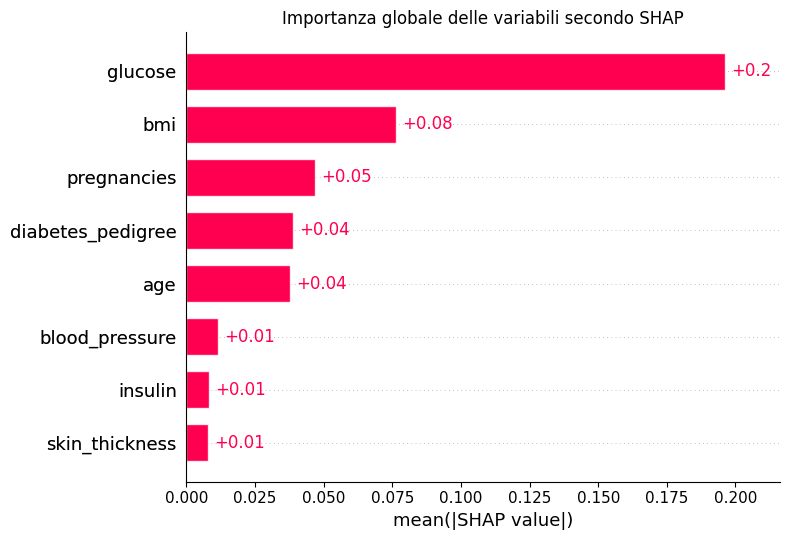

,Variabile,Contributo medio assoluto
1,glucose,0.1961
5,bmi,0.0763
0,pregnancies,0.0468
6,diabetes_pedigree,0.0389
7,age,0.0378
2,blood_pressure,0.0113
4,insulin,0.0082
3,skin_thickness,0.0078


In [3]:
shap.plots.bar(shap_values, max_display=len(FEATURES), show=False)
plt.title('Importanza globale delle variabili secondo SHAP')
plt.tight_layout()
plt.show()

global_importance = pd.DataFrame({
    'Variabile': FEATURES,
    'Contributo medio assoluto': np.abs(shap_values.values).mean(axis=0),
}).sort_values('Contributo medio assoluto', ascending=False)
display(global_importance.round(4))

### Direzione dei contributi nel campione

Il grafico a barre precedente usa i valori assoluti e quindi non mostra la direzione dell'effetto. Il beeswarm aggiunge questa informazione per le 30 osservazioni analizzate: ogni punto rappresenta un'osservazione, il colore indica se il valore originale della variabile è alto (rosso) o basso (blu), mentre la posizione orizzontale indica se quel valore aumenta o riduce la probabilità.

> **Lettura rapida:** punti a destra aumentano la probabilità stimata della classe 1; punti a sinistra la riducono. Rosso e blu descrivono il valore della variabile, non un giudizio positivo o negativo.

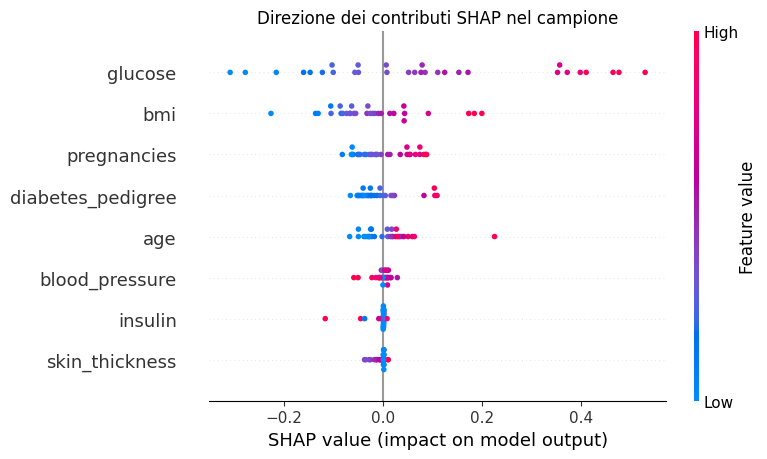

In [4]:
shap.plots.beeswarm(shap_values, max_display=len(FEATURES), show=False)
plt.title('Direzione dei contributi SHAP nel campione')
plt.tight_layout()
plt.show()

## 4. Spiegazione locale di una predizione

La spiegazione locale mostra come le caratteristiche di una singola osservazione spostano la predizione rispetto al valore di riferimento. Le barre rosse aumentano la probabilità stimata, quelle blu la riducono. La somma del valore di riferimento e dei contributi delle otto variabili ricostruisce la probabilità prevista dal modello.

Nell'esempio seleziono la prima riga del test set. Nel CSV originale insulina e spessore cutaneo valgono 0: per queste misure lo zero non è plausibile e viene quindi trasformato in valore mancante, poi sostituito dalla mediana calcolata sul training set. Non sto quindi interpretando uno zero fisiologico.

In questo grafico mantengo invece il segno dei contributi: una barra positiva aumenta la probabilità stimata, mentre una barra negativa la riduce.

Probabilità stimata: 0.7222


,Variabile,Valore inserito,Contributo SHAP
1,glucose,159.000,0.3524
5,bmi,27.400,-0.0864
0,pregnancies,7.000,0.0484
7,age,40.000,0.0323
6,diabetes_pedigree,0.294,-0.0226
2,blood_pressure,64.000,0.0090
4,insulin,0.000,0.0018
3,skin_thickness,0.000,0.0018


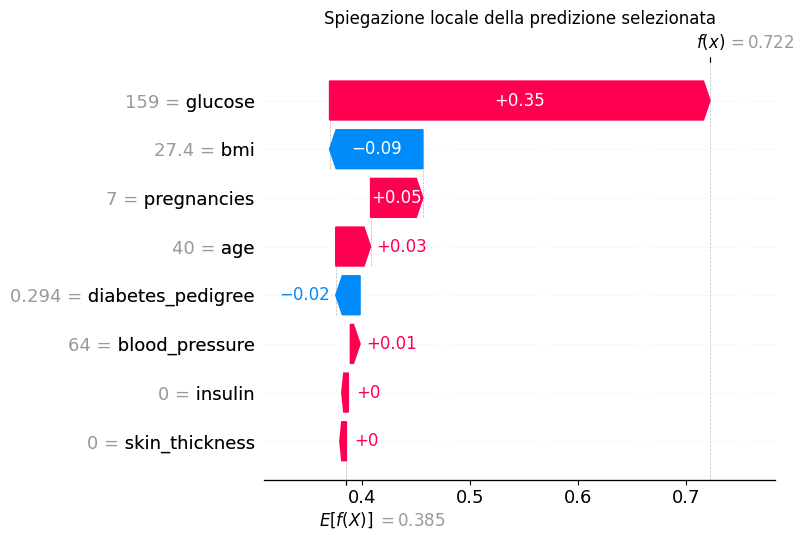

In [5]:
row_index = 0
row = explain_data.iloc[row_index]
probability = float(model.predict_proba(pd.DataFrame([row], columns=FEATURES))[0, 1])
print('Probabilità stimata:', round(probability, 4))
display(pd.DataFrame({'Variabile': FEATURES, 'Valore inserito': row.values, 'Contributo SHAP': shap_values.values[row_index]}).sort_values('Contributo SHAP', key=np.abs, ascending=False).round(4))

shap.plots.waterfall(shap_values[row_index], max_display=len(FEATURES), show=False)
plt.title('Spiegazione locale della predizione selezionata')
plt.tight_layout()
plt.show()

## 5. Analisi esplorativa dei possibili bias

Divido il dataset in 80% training set e 20% test set, mantenendo la stessa suddivisione stratificata usata nella valutazione dei modelli. Per questo confronto uso una nuova istanza della stessa pipeline, addestrata soltanto sulle 614 osservazioni del training set; poi applico il modello alle 154 osservazioni del test set e calcolo le metriche separatamente per tre fasce: fino a 29 anni, 30–49 anni e almeno 50 anni. In questo modo le osservazioni del test set restano indipendenti dalla fase di addestramento. Il modello salvato per l'applicazione, invece, è stato riaddestrato su tutti i dati disponibili e viene usato nelle spiegazioni SHAP.

Le metriche possono essere diverse perché i gruppi non contengono persone equivalenti: cambiano la distribuzione di glucosio, BMI e degli altri parametri, la proporzione di casi positivi e il numero di osservazioni. La tabella riporta anche i casi positivi e la prevalenza della classe 1, così posso distinguere una differenza di prestazioni da una semplice differenza nella composizione dei gruppi. Inoltre applico a tutti la stessa soglia di classificazione, pari a 0,5, che può funzionare meglio per alcuni gruppi. Queste differenze descrivono il comportamento del modello sui dati osservati, ma non dimostrano da sole la presenza di discriminazione.

Questa analisi non dimostra da sola la presenza o l'assenza di bias: le fasce possono avere numerosità ridotte e l'età è soltanto una delle possibili dimensioni di confronto. Serve però a evidenziare eventuali differenze che richiederebbero una validazione più approfondita.

,Osservazioni,Casi positivi,Prevalenza classe 1,Accuracy,Precision,Recall,F1-score
Fascia di età,,,,,,,
fino a 29 anni,85,16,0.188,0.753,0.368,0.438,0.400
30-49 anni,54,32,0.593,0.722,0.758,0.781,0.769
50 anni o più,15,6,0.400,0.667,0.556,0.833,0.667


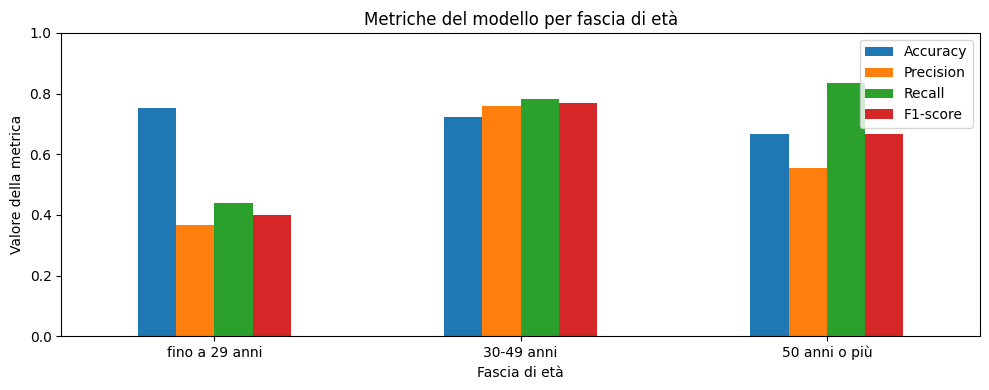

In [6]:
predictions = evaluation_model.predict(X_test)
age_groups = pd.cut(
    X_test['age'], bins=[0, 29, 49, np.inf],
    labels=['fino a 29 anni', '30-49 anni', '50 anni o più']
)

group_rows = []
for group in age_groups.cat.categories:
    indexes = age_groups[age_groups == group].index
    if len(indexes) == 0:
        continue
    group_rows.append({
        'Fascia di età': group,
        'Osservazioni': len(indexes),
        'Casi positivi': int(y_test.loc[indexes].sum()),
        'Prevalenza classe 1': y_test.loc[indexes].mean(),
        'Accuracy': accuracy_score(y_test.loc[indexes], predictions[X_test.index.get_indexer(indexes)]),
        'Precision': precision_score(y_test.loc[indexes], predictions[X_test.index.get_indexer(indexes)], zero_division=0),
        'Recall': recall_score(y_test.loc[indexes], predictions[X_test.index.get_indexer(indexes)], zero_division=0),
        'F1-score': f1_score(y_test.loc[indexes], predictions[X_test.index.get_indexer(indexes)], zero_division=0),
    })
bias_results = pd.DataFrame(group_rows).set_index('Fascia di età').round(3)
display(bias_results)

bias_results[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(kind='bar', figsize=(10, 4), ylim=(0, 1), rot=0)
plt.title('Metriche del modello per fascia di età')
plt.ylabel('Valore della metrica')
plt.tight_layout()
plt.show()

## 6. Conclusioni e limiti

> **Risultato principale:** nel campione analizzato, **glucosio** e **BMI** sono le due variabili che influenzano maggiormente le probabilità stimate dal modello.

Gravidanze, storia familiare del diabete ed età hanno un contributo medio più contenuto, mentre pressione sanguigna, insulina e spessore della pelle incidono meno. Questo descrive il comportamento del modello sui dati disponibili: non dimostra che una variabile sia una causa della malattia.

Il confronto per età mostra che le metriche non sono identiche nei tre gruppi. In particolare, il gruppo fino a 29 anni ha un recall più basso, mentre il gruppo tra 30 e 49 anni ottiene risultati migliori. Il gruppo di 50 anni o più contiene però soltanto 15 osservazioni nel test set: una differenza osservata su un gruppo così piccolo può dipendere anche dal caso. Considero quindi questo risultato come un segnale da approfondire, non come una prova di bias.

SHAP mi permette di spiegare sia quali variabili sono importanti in generale sia perché una singola osservazione riceve una determinata probabilità. Questa informazione può migliorare la trasparenza dell'applicazione, ma non trasforma il modello in uno strumento clinico. Per una valutazione seria della fairness servirebbero gruppi definiti con una motivazione statistica, numerosità adeguate, intervalli di confidenza e una validazione su dati indipendenti.